# Exploratory Data Analysis on India's COVID-19 Data

## Objective
The objective of this project is to analyse India's COVID-19 data using NumPy, Pandas, Matplotlib, and Seaborn. The project studies state-wise confirmed cases, recoveries, deaths, recovery rates, death rates, and India's vaccination progress using tables, statistical calculations, and visualisations.

## Tools Used
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook / Google Colab

## Data Sources
1. COVID-19 case data: [imdevskp/covid-19-india-data](https://github.com/imdevskp/covid-19-india-data)
2. Vaccination data: [Our World in Data](https://github.com/owid/covid-19-data)

## Expected Outcome
To identify important patterns in India's early COVID-19 outbreak and understand the growth of the national vaccination programme through exploratory data analysis and 12 charts.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Data

In [3]:
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"
)

print("Cases shape:", cases.shape)
print("Vaccination shape:", vax.shape)
cases.head()

Cases shape: (4692, 10)
Vaccination shape: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


## 3. Inspect Before Touching Anything

In [4]:
cases.dtypes

Date                          object
Name of State / UT            object
Latitude                     float64
Longitude                    float64
Total Confirmed cases        float64
Death                         object
Cured/Discharged/Migrated    float64
New cases                      int64
New deaths                     int64
New recovered                  int64
dtype: object

In [5]:
cases.isna().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [6]:
print("Number of unique state/UT names:", cases["Name of State / UT"].nunique())
sorted(cases["Name of State / UT"].unique())

Number of unique state/UT names: 40


['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Telangana***',
 'Telengana',
 'Tripura',
 'Union Territory of Chandigarh',
 'Union Territory of Jammu and Kashmir',
 'Union Territory of Ladakh',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

### Problems Identified During Data Inspection

During the initial inspection, two important data-quality issues were identified:

1. **Incorrect data type:** The `Death` column is stored as an object instead of a numeric data type, possibly because of unwanted characters. This must be investigated before converting it.

2. **Inconsistent state names:** Names such as `Telangana`, `Telengana`, and `Telangana***` refer to the same state. Similarly, some Union Territories may appear with and without the prefix `Union Territory of`.

These issues can lead to incorrect calculations and duplicate state-level entries. Therefore, we will correct them before performing exploratory data analysis.

## 4. Clean the Data

In [11]:
# Rename to clean, snake_case column names
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",
]

# Fix data types
cases["date"] = pd.to_datetime(cases["date"])
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)
cases["confirmed"] = cases["confirmed"].astype(int)
cases["cured"] = cases["cured"].astype(int)

# Fix inconsistent state names
name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)

# Drop any exact duplicate (date, state) rows this merge might create
cases = cases.drop_duplicates(subset=["date", "state"]).sort_values(["state", "date"]).reset_index(drop=True)

# A derived column: active cases = confirmed - deaths - recovered
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]

print("Clean state count:", cases["state"].nunique())
cases.dtypes

Clean state count: 35


date             datetime64[ns]
state                    object
lat                     float64
long                    float64
confirmed                 int64
deaths                    int64
cured                     int64
new_cases                 int64
new_deaths                int64
new_recovered             int64
active                    int64
dtype: object

In [12]:
cases.isna().sum().sum()   # should be 0 -- fully clean now

np.int64(0)

## 5. National-Level Summary (groupby)

In [13]:
national = cases.groupby("date", as_index=False)[["confirmed", "deaths", "cured"]].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)
national["death_rate"] = (national["deaths"] / national["confirmed"] * 100).round(2)
national["new_confirmed"] = national["confirmed"].diff().fillna(national["confirmed"])

national.tail()

,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed
181,2020-08-02,1750723,37364,1145629,65.44,2.13,54735.0
182,2020-08-03,1803695,38135,1186203,65.77,2.11,52972.0
183,2020-08-04,1855745,38938,1230509,66.31,2.10,52050.0
184,2020-08-05,1908254,39795,1282215,67.19,2.09,52509.0
185,2020-08-06,1964536,40699,1328336,67.62,2.07,56282.0


In [15]:
latest_date = cases["date"].max()
latest_row = national.iloc[-1]

print(f"As of {latest_date.date()}:")
print(f"  Total confirmed : {latest_row['confirmed']:,}")
print(f"  Total recovered : {latest_row['cured']:,}")
print(f"  Total deaths    : {latest_row['deaths']:,}")
print(f"  Recovery rate   : {latest_row['recovery_rate']}%")
print(f"  Death rate      : {latest_row['death_rate']}%")

As of 2020-08-06:
  Total confirmed : 1,964,536
  Total recovered : 1,328,336
  Total deaths    : 40,699
  Recovery rate   : 67.62%
  Death rate      : 2.07%


## 6. State-Wise Snapshot (latest date)

In [17]:
latest = cases[cases["date"] == latest_date].copy()
latest["recovery_rate"] = (latest["cured"] / latest["confirmed"] * 100).round(2)
latest["death_rate"] = (latest["deaths"] / latest["confirmed"] * 100).round(2)
latest = latest.sort_values("confirmed", ascending=False).reset_index(drop=True)

top10 = latest.head(10)
top10[["state", "confirmed", "deaths", "cured", "recovery_rate", "death_rate"]]

,state,confirmed,deaths,cured,recovery_rate,death_rate
0,Maharashtra,468265,16476,305521,65.25,3.52
1,Tamil Nadu,273460,4461,214815,78.55,1.63
2,Andhra Pradesh,186461,1681,104354,55.97,0.90
3,Karnataka,151449,2804,74679,49.31,1.85
4,Delhi,140232,4044,126116,89.93,2.88
5,Uttar Pradesh,104388,1857,60558,58.01,1.78
6,West Bengal,83800,1846,58962,70.36,2.20
7,Telangana,73050,589,52103,71.33,0.81
8,Gujarat,66669,2556,49433,74.15,3.83
9,Bihar,64770,355,42414,65.48,0.55


In [18]:
cases["month"] = cases["date"].dt.strftime("%Y-%m")
month_pivot = cases[cases["state"].isin(top10["state"].head(5))].pivot_table(
    values="new_cases", index="state", columns="month", aggfunc="sum", fill_value=0
)
month_pivot

month,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,
Andhra Pradesh,39,1292,2237,10322,116666,55904
Delhi,96,3342,15110,66612,49242,5829
Karnataka,82,452,2387,11373,104337,32817
Maharashtra,218,9699,55253,104715,241915,56467
Tamil Nadu,73,2088,19022,65040,153754,33482


## 7. Visualisations (12 charts)

## Chart 1 — National cumulative trend

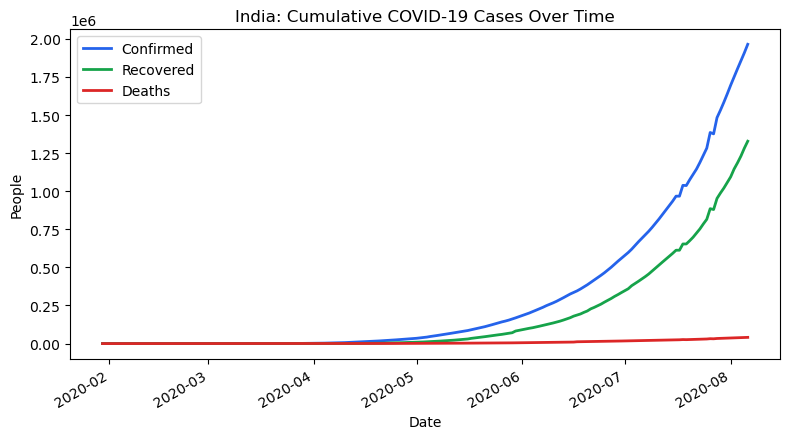

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["confirmed"], label="Confirmed", color="#2563eb", lw=2)
ax.plot(national["date"], national["cured"], label="Recovered", color="#16a34a", lw=2)
ax.plot(national["date"], national["deaths"], label="Deaths", color="#dc2626", lw=2)
ax.set_title("India: Cumulative COVID-19 Cases Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("People")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Chart 2 — Daily new confirmed cases

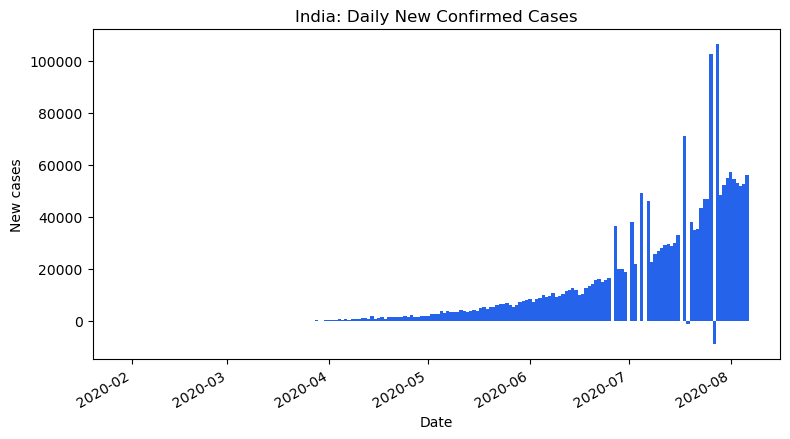

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(national["date"], national["new_confirmed"], color="#2563eb", width=1.0)
ax.set_title("India: Daily New Confirmed Cases")
ax.set_xlabel("Date"); ax.set_ylabel("New cases")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Chart 3 — Top 10 states by total confirmed cases

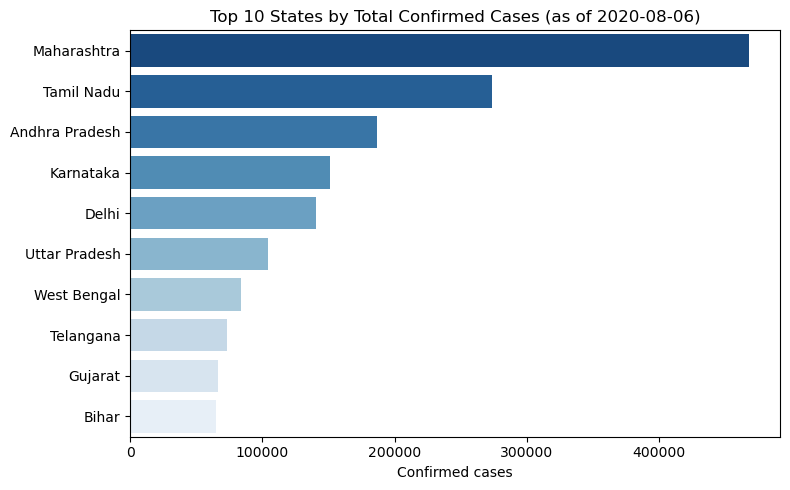

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y="state", x="confirmed", hue="state", palette="Blues_r", legend=False, ax=ax)
ax.set_title(f"Top 10 States by Total Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Chart 4 — Recovery rate of the 10 worst-hit states

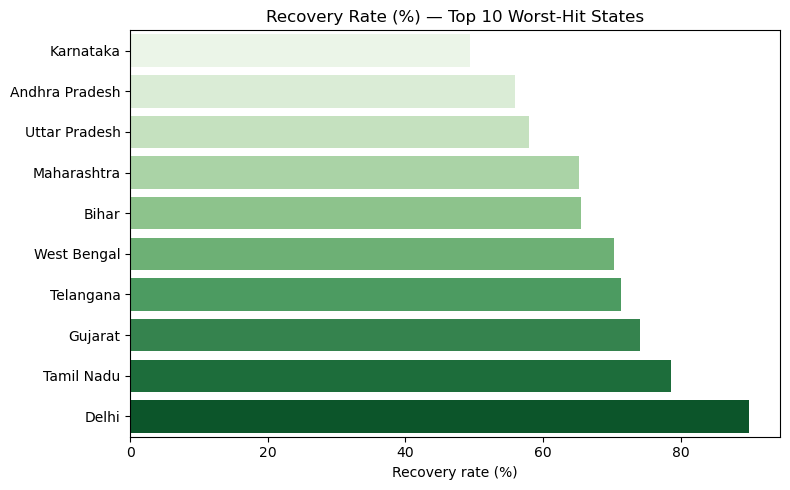

In [22]:
top10_sorted = top10.sort_values("recovery_rate")
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10_sorted, y="state", x="recovery_rate", hue="state", palette="Greens", legend=False, ax=ax)
ax.set_title("Recovery Rate (%) — Top 10 Worst-Hit States")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Chart 5 — Confirmed-case trend for the top 5 states

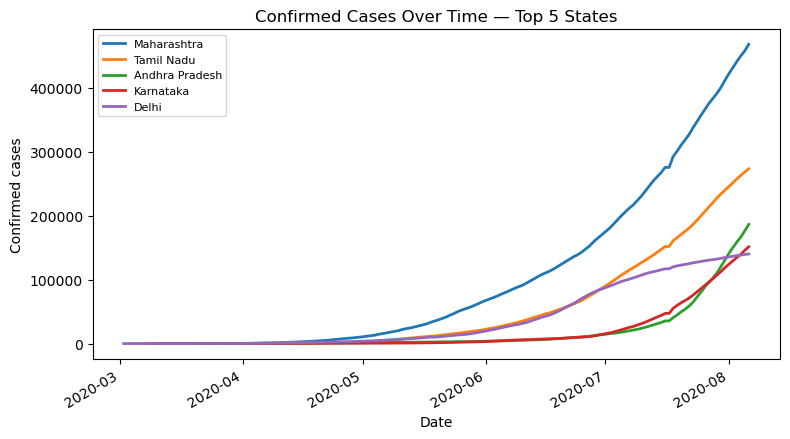

In [23]:
top5_states = top10["state"].head(5).tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
for s in top5_states:
    sub = cases[cases["state"] == s]
    ax.plot(sub["date"], sub["confirmed"], label=s, lw=2)
ax.set_title("Confirmed Cases Over Time — Top 5 States")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Chart 6 — Share of national cases by state (pie)

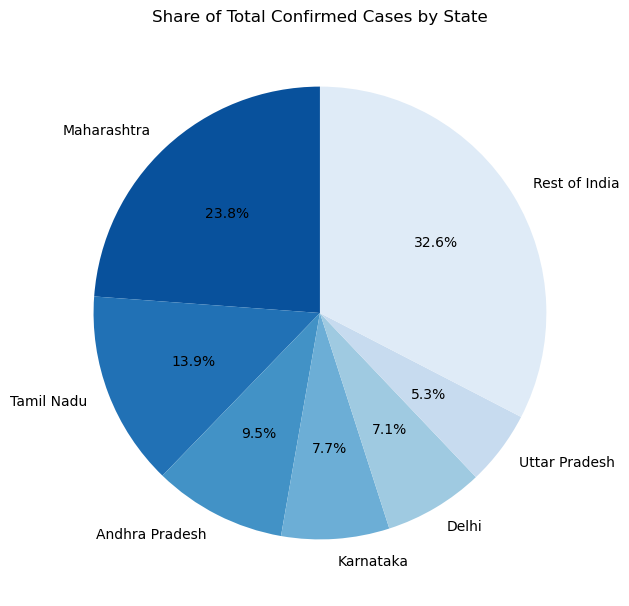

In [24]:
top6 = latest.nlargest(6, "confirmed")[["state", "confirmed"]]
others = latest["confirmed"].sum() - top6["confirmed"].sum()
pie_labels = top6["state"].tolist() + ["Rest of India"]
pie_values = top6["confirmed"].tolist() + [others]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("Blues_r", 7))
ax.set_title("Share of Total Confirmed Cases by State")
plt.tight_layout()
plt.show()

## Chart 7 — National recovery-rate trend

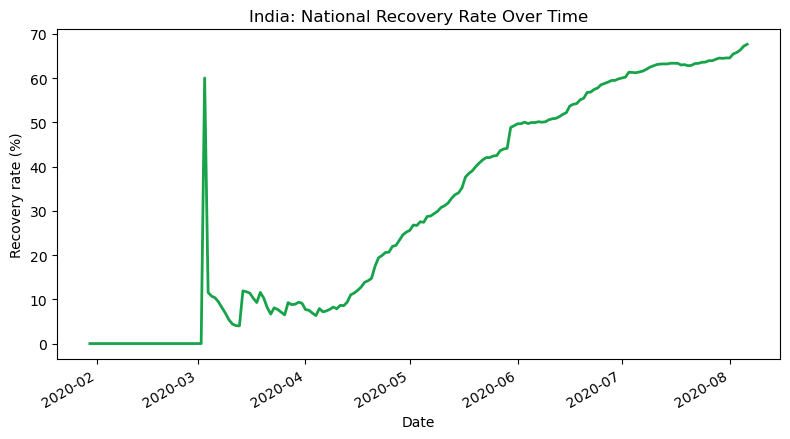

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["recovery_rate"], color="#16a34a", lw=2)
ax.set_title("India: National Recovery Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Recovery rate (%)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Chart 8 — Recovery rate vs death rate, by state (bubble = case count)

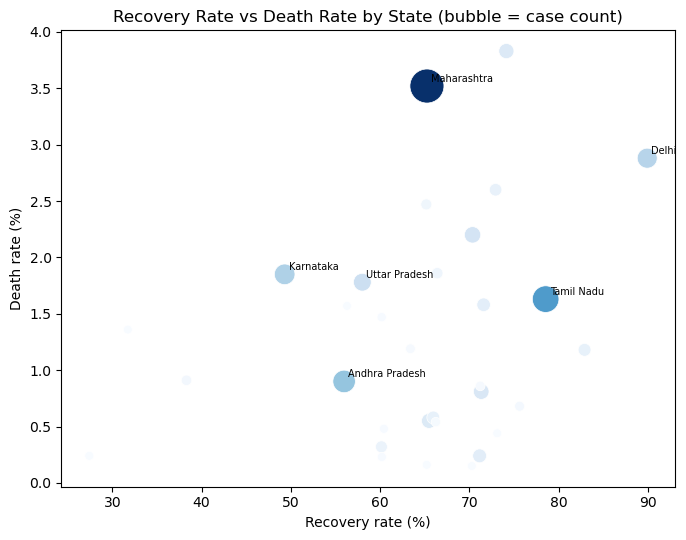

In [27]:
sizeable = latest[latest["confirmed"] >= 1000]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=sizeable, x="recovery_rate", y="death_rate", size="confirmed",
                 sizes=(40, 600), hue="confirmed", palette="Blues", legend=False, ax=ax)
for _, r in sizeable.nlargest(6, "confirmed").iterrows():
    ax.annotate(r["state"], (r["recovery_rate"], r["death_rate"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_title("Recovery Rate vs Death Rate by State (bubble = case count)")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("Death rate (%)")
plt.tight_layout()
plt.show()

## Chart 9 — Correlation heatmap of national metrics

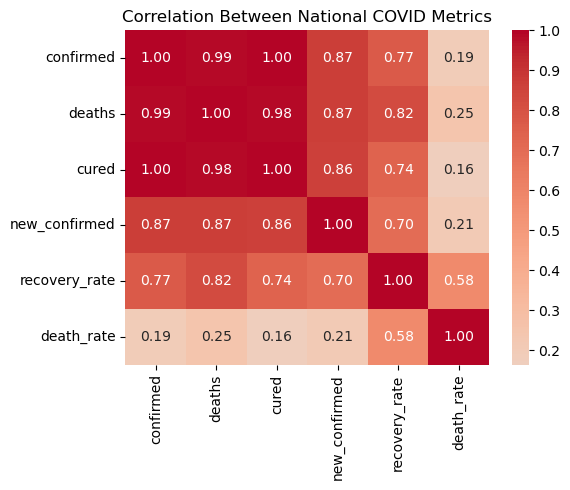

In [28]:
corr_cols = ["confirmed", "deaths", "cured", "new_confirmed", "recovery_rate", "death_rate"]
corr = national[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between National COVID Metrics")
plt.tight_layout()
plt.show()

## Chart 10 — Spread of daily new cases, by month (boxplot)

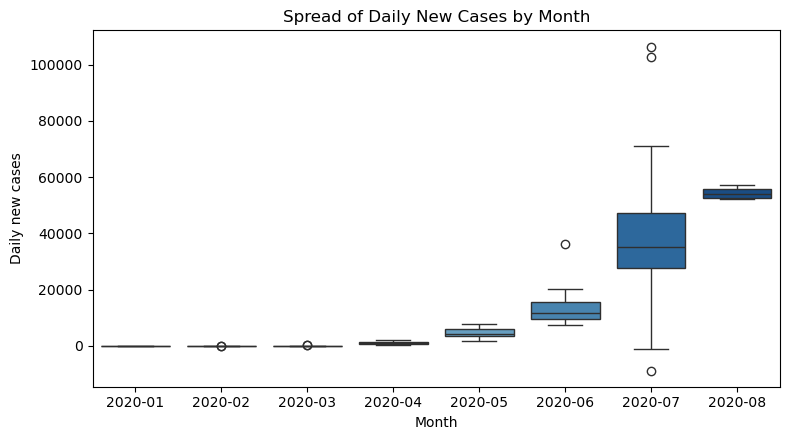

In [29]:
national["month"] = national["date"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=national, x="month", y="new_confirmed", hue="month", palette="Blues", legend=False, ax=ax)
ax.set_title("Spread of Daily New Cases by Month")
ax.set_xlabel("Month"); ax.set_ylabel("Daily new cases")
plt.tight_layout()
plt.show()

## Chart 11 — India's vaccination progress (2021-2024)

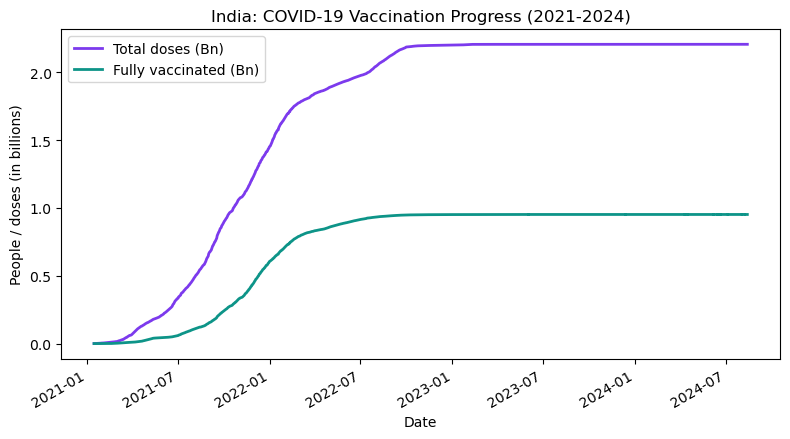

In [30]:
vax["date"] = pd.to_datetime(vax["date"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vax["date"], vax["total_vaccinations"] / 1e9, label="Total doses (Bn)", color="#7c3aed", lw=2)
ax.plot(vax["date"], vax["people_fully_vaccinated"] / 1e9, label="Fully vaccinated (Bn)", color="#0d9488", lw=2)
ax.set_title("India: COVID-19 Vaccination Progress (2021-2024)")
ax.set_xlabel("Date"); ax.set_ylabel("People / doses (in billions)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Chart 12 — The 10 least-affected states/UTs

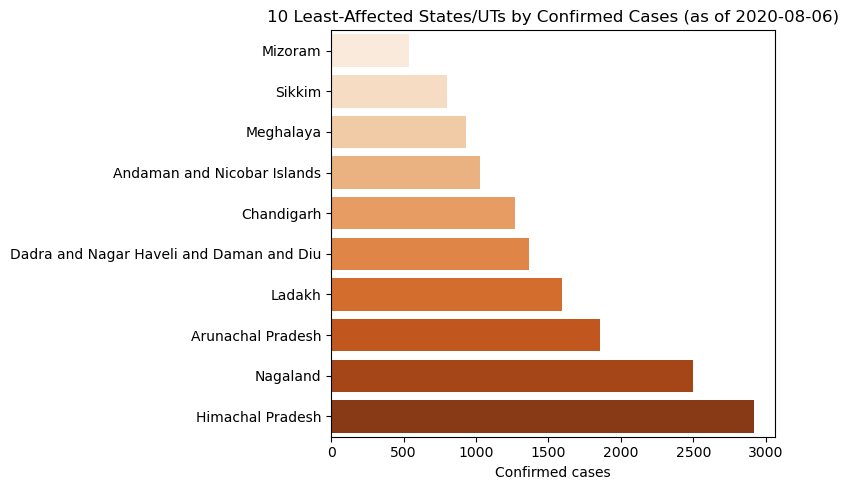

In [31]:
bottom10 = latest[latest["confirmed"] > 0].nsmallest(10, "confirmed")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=bottom10, y="state", x="confirmed", hue="state", palette="Oranges", legend=False, ax=ax)
ax.set_title(f"10 Least-Affected States/UTs by Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Save the Cleaned Dataset

In [32]:
cases.to_csv("cleaned_covid_india.csv", index=False)
print("Saved cleaned_covid_india.csv —", cases.shape[0], "rows.")

Saved cleaned_covid_india.csv — 4692 rows.


## 9. Written Summary

### 9.1 Coverage

The dataset covers 35 Indian states and Union Territories over 186 days, from 30 January 2020 to 6 August 2020. It represents the early stage of India's COVID-19 pandemic.

### 9.2 National Picture

By the end of the data period, India had recorded approximately 19.6 lakh confirmed cases, 13.3 lakh recoveries, and 40,700 deaths. The recovery rate was around 68%, while the death rate was approximately 2.1%.

Daily new cases were still increasing rapidly, indicating that the outbreak had not yet reached its peak within this dataset's time window.

### 9.3 State-wise Concentration

COVID-19 cases were concentrated in a few states. Maharashtra accounted for a substantial share of the national total, followed by states such as Tamil Nadu, Andhra Pradesh, Karnataka, and Delhi.

This shows that the spread of COVID-19 was uneven across India.

### 9.4 Recovery Rate Differences

Recovery rates varied across states. Delhi recorded a relatively high recovery rate, while Karnataka had a lower rate at the selected snapshot.

These differences may reflect variations in the timing of outbreaks, reporting practices, and the time taken for patients to recover.

### 9.5 Death Rate Differences

Death rates also differed across states. Gujarat recorded a relatively high death rate among heavily affected states, while some other states had lower recorded rates.

Possible factors for further investigation include healthcare access, population demographics, testing practices, and reporting differences. The dataset alone cannot establish the causes of these variations.

### 9.6 Vaccination Progress

India's vaccination programme began in January 2021, after the case dataset ended. The separate vaccination dataset allows us to study the subsequent public health response and the expansion of vaccination across the country.

Vaccination totals should be interpreted carefully because the number of doses administered is different from the number of people vaccinated.

### 9.7 Limitations

The dataset may contain inconsistencies due to differences in state-level reporting. Data cleaning helps address incorrect data types, inconsistent state names, and duplicate records.

Recovery and death rates calculated from cumulative totals are simple descriptive measures. They do not account for reporting delays or differences in the timing of outcomes. Therefore, the results should be interpreted as historical trends rather than precise clinical estimates.

### 9.8 Conclusion

This exploratory data analysis demonstrates how Python libraries such as NumPy, Pandas, Matplotlib, and Seaborn can be used to examine COVID-19 trends in India. The analysis highlights state-wise differences, national case trends, recovery and death rates, and the later progress of vaccination.

Overall, the project shows how data cleaning, statistical analysis, and visualisation help transform raw public health data into meaningful insights.